# Умный модератор комментариев 2.0

## Цель проекта

Цель проекта - разработать современную систему автоматической классификации комментариев на токсичные и нетоксичные с использованием трансформерной модели RuBERT.

В отличие от классического подхода TF-IDF + Logistic Regression, в данном проекте используется предобученная нейронная сеть семейства BERT, позволяющая учитывать контекст слов и смысл всего предложения.

Дополнительно будет реализован REST API на FastAPI, позволяющий использовать модель как отдельный сервис.

---

## Задачи проекта

- исследовать датасет;
- подготовить данные для обучения;
- выполнить токенизацию текста;
- дообучить модель RuBERT;
- оценить качество модели;
- сравнить результаты с классической Logistic Regression;
- сохранить модель;
- реализовать REST API.

# 1. Импорт библиотек

Импортируем библиотеки, необходимые для загрузки данных, обучения модели, оценки качества и визуализации результатов.

In [15]:
import warnings
warnings.filterwarnings("ignore")

import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from datasets import Dataset
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    DataCollatorWithPadding,
    Trainer
)
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 2. Проверка устройства

Определим, какое устройство будет использоваться для обучения модели.

Если доступно ускорение Apple Silicon (MPS), обучение будет выполняться на GPU.

In [18]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Используемое устройство: {device}")

Используемое устройство: mps


# 3. Загрузка и исследование данных

Перед обучением модели необходимо изучить датасет.

На данном этапе проверим:

- размер набора данных;
- наличие пропусков;
- баланс классов;
- примеры комментариев;
- длину комментариев.

Это позволит лучше понять данные и заранее выявить возможные проблемы.

In [21]:
df=pd.read_csv("../data/labeled.csv")

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14412 entries, 0 to 14411
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   comment  14412 non-null  str    
 1   toxic    14412 non-null  float64
dtypes: float64(1), str(1)
memory usage: 4.6 MB


In [25]:
df.isna().sum()

comment    0
toxic      0
dtype: int64

### Проверка пропусков

Для корректного обучения модели необходимо убедиться, что в данных отсутствуют пропущенные значения.

При наличии пропусков их потребуется удалить или обработать.

In [28]:
df.sample(10)

,comment,toxic
3319,"А как доставка? Что по деньгам, как пакуют, ка...",0.0
8266,Объясните только пару моментов - Каким образом...,0.0
8285,Так продают и не рядовые люди. И этот вопрос н...,0.0
10175,Конкретно возле этого села есть минеральный ис...,0.0
11900,"Нифига подобного, эрекция всегда одной длинны,...",0.0
13779,"Израиль. Спецподразделения армии, полиции и ША...",1.0
12711,На авито эта карта уже год привязана никаких п...,0.0
7851,Продолжай смотреть Скабееву и т.д жаль конечно...,1.0
4383,"Хз кто там покупает, я в такие магазины захожу...",0.0
8161,"Все, дошло, спасибо большое\n",0.0


### Первичный анализ

Просмотр случайных комментариев позволяет понять структуру текста, наличие жаргона, нецензурной лексики, ссылок, эмодзи и других особенностей датасета.

In [31]:
class_counts = df["toxic"].value_counts()

class_counts

toxic
0.0    9586
1.0    4826
Name: count, dtype: int64

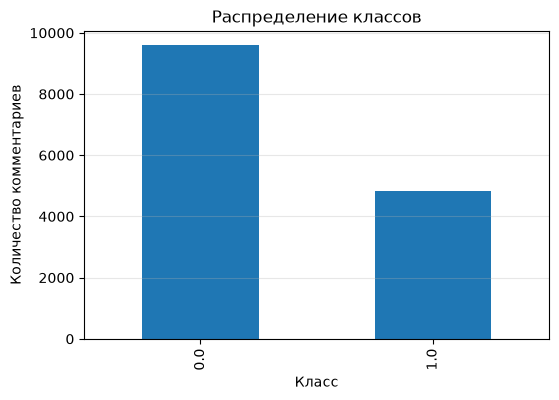

In [33]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество комментариев")
plt.grid(axis="y", alpha=0.3)
plt.savefig(
    "../images/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Вывод по распределению классов

Датасет содержит умеренный дисбаланс классов.

Нетоксичные комментарии составляют около 66% выборки, токсичные — около 34%.

Такое распределение не является критичным, однако при обучении модели важно использовать метрики Precision, Recall и F1-score, а не только Accuracy.

### Анализ распределения классов

Перед обучением модели важно оценить баланс классов.

При сильном дисбалансе модель может чаще предсказывать наиболее распространенный класс, что ухудшает качество классификации.

In [37]:
df["length"] = df["comment"].str.len()

In [39]:
df["length"].describe()

count    14412.000000
mean       176.525812
std        271.612376
min         21.000000
25%         57.000000
50%        101.000000
75%        197.000000
max       7404.000000
Name: length, dtype: float64

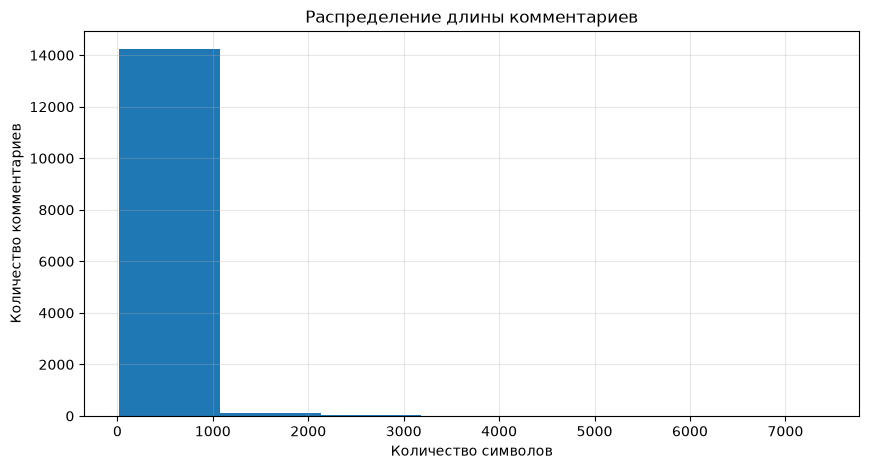

In [41]:
plt.figure(figsize=(10,5))
plt.hist(df["length"], bins=7)
plt.title("Распределение длины комментариев")
plt.xlabel("Количество символов")
plt.ylabel("Количество комментариев")
plt.grid(alpha=0.3)
plt.show()

### Сравнение длины комментариев по классам

Дополнительно сравним длину токсичных и нетоксичных комментариев.

Это позволит понять, существует ли зависимость между длиной сообщения и его классом.

In [44]:
length_stats = (
    df.groupby("toxic")["length"]
      .agg(["mean", "median", "min", "max"])
)

length_stats

,mean,median,min,max
toxic,,,,
0.0,194.213332,118.0,21,7404
1.0,141.392665,76.0,21,5218


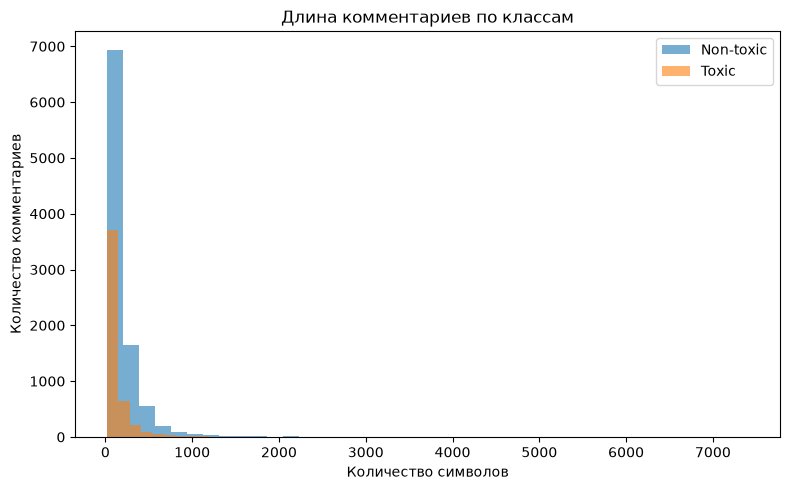

In [46]:
plt.figure(figsize=(8,5))

for label, name in zip([0,1], ["Non-toxic", "Toxic"]):
    plt.hist(
        df[df["toxic"]==label]["length"],
        bins=40,
        alpha=0.6,
        label=name
    )

plt.xlabel("Количество символов")
plt.ylabel("Количество комментариев")
plt.title("Длина комментариев по классам")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../images/comment_length_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Вывод

Распределения длин комментариев частично пересекаются.

Это означает, что длина текста сама по себе не является достаточным признаком токсичности, однако может содержать дополнительную информацию для модели.

### Анализ длины комментариев

Большинство современных трансформерных моделей имеют ограничение на максимальную длину входного текста.

Поэтому важно оценить распределение длин комментариев, чтобы в дальнейшем выбрать подходящее значение параметра `max_length`.

In [50]:
df.sort_values("length", ascending=False).head(10)

,comment,toxic,length
2064,С начала года свыше 40 тысяч россиян объявили ...,0.0,7404
3016,"Блеаадь, как же обидно когда создаешь тред, па...",1.0,5218
5795,С 19 апреля в Николаеве будет действовать запр...,0.0,5174
1953,"В Киеве на вокзале Мен було рок в 19, коли мен...",1.0,4921
13688,Агентство DARPA в 2020 году планирует начать р...,0.0,4544
214,"Раз уж вакханалия продолжается, давайте в этом...",0.0,4371
1628,"именно так. смотрю на тебя, стаса, вестника ду...",1.0,4214
9205,"Рад, что Вы допускаете пользу от маркетинга. В...",0.0,4177
659,"Знаете, моя подруга живёт с мужчиной, который ...",1.0,3928
1660,"дерейлы тредов за счёт постоянных провокаций, ...",1.0,3805


In [52]:
df.sort_values("length").head(10)

,comment,toxic,length
1595,Я бы Тармашева забрал,0.0,21
1893,Бауманка астанавитесь,0.0,21
1737,ПАПИЧ ЛУЧШИЙ НА ТРИПЛ,1.0,21
1388,Малышь (подвегаеться),0.0,21
1855,Не читай так больше)),0.0,21
1842,но она же красивая...,0.0,21
1197,залупа из лиственницы,1.0,21
1299,А сколько у нас шпаг?,0.0,21
1124,Ничего он не узнал )),0.0,21
1084,"После маски,лицо жмет",0.0,21


# 4. Подготовка данных

Для моделей семейства BERT не требуется классическая предобработка текста (удаление стоп-слов, стемминг, лемматизация).

Предобученная модель самостоятельно учитывает форму слов, порядок слов и контекст предложения.

Поэтому в данном проекте исходный текст будет использоваться практически без изменений.

In [55]:
df = df[["comment", "toxic"]].copy()

In [57]:
df.dtypes

comment        str
toxic      float64
dtype: object

In [59]:
df["toxic"] = df["toxic"].astype(int)

In [61]:
df.head()

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1
1,"Хохлы, это отдушина затюканого россиянина, мол...",1
2,Собаке - собачья смерть\n,1
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1


In [63]:
train_df,test_df=train_test_split(df, random_state=42, test_size=0.2, stratify=df["toxic"])

## Проверка разбиения выборки

После разделения данных необходимо убедиться, что соотношение классов сохранилось в обучающей и тестовой выборках.

Для этого используется стратифицированное разбиение (stratify), которое предотвращает изменение распределения классов.

In [65]:
print(f"Обучающая выборка: {len(train_df)}")
print(f"Тестовая выборка: {len(test_df)}")

Обучающая выборка: 11529
Тестовая выборка: 2883


In [67]:
print(train_df["toxic"].value_counts(normalize=True))

print('-'*35)

print(test_df["toxic"].value_counts(normalize=True))

toxic
0    0.665105
1    0.334895
Name: proportion, dtype: float64
-----------------------------------
toxic
0    0.665279
1    0.334721
Name: proportion, dtype: float64


# 5. Токенизация текста

Нейронная сеть не может работать напрямую со строками.

Поэтому текст преобразуется в последовательность специальных токенов с помощью токенизатора RuBERT.

На этом этапе будут:

- загружен токенизатор;
- выбрана максимальная длина последовательности;
- выполнено преобразование текста в числовое представление.

In [70]:
MODEL_NAME = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [71]:
token_lengths = df["comment"].apply(
    lambda text: len(tokenizer.tokenize(text))
)

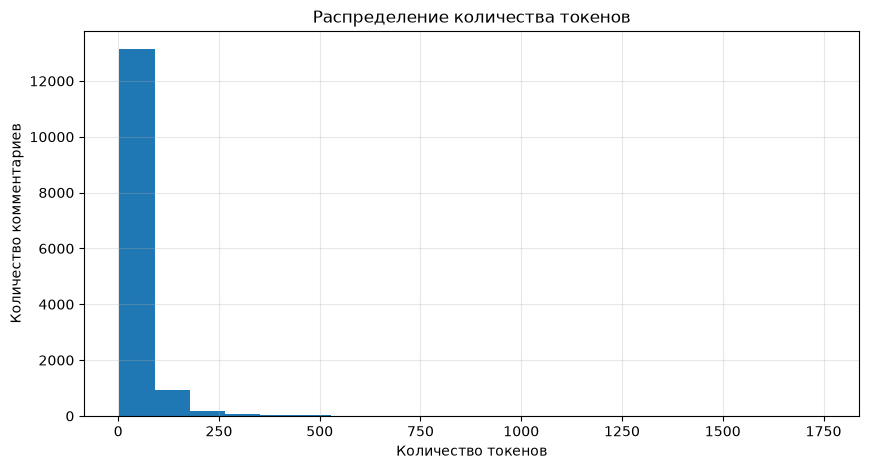

In [74]:
plt.figure(figsize=(10,5))
plt.hist(token_lengths, bins=20)
plt.title("Распределение количества токенов")
plt.xlabel("Количество токенов")
plt.ylabel("Количество комментариев")
plt.grid(alpha=0.3)
plt.savefig(
    "../images/token_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



In [76]:
print(token_lengths.quantile(0.90))
print(token_lengths.quantile(0.95))
print(token_lengths.quantile(0.99))

85.0
122.0
265.8899999999994


Выбираем **max_length = 128**

- покрываем более 95% комментариев полностью;
- обучение будет заметно быстрее, чем при 256 или 512;
- для задачи бинарной классификации это разумный компромисс.

# 6. Подготовка данных для обучения

Для обучения модели Hugging Face используется объект `Dataset`.

На данном этапе обучающая и тестовая выборки преобразуются из `pandas.DataFrame` в формат `Dataset`, после чего будет выполнена токенизация текста.

In [80]:
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['comment', 'toxic'],
    num_rows: 11529
})
Dataset({
    features: ['comment', 'toxic'],
    num_rows: 2883
})


**Dataset:**
 - быстрее работает с большими данными;
 - поддерживает батчи;
 - умеет лениво применять преобразования (map);
 - напрямую интегрируется с Trainer

In [83]:
MAX_LENGTH = 128

def tokenize_function(examples):
    return tokenizer(
        examples["comment"],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [85]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/11529 [00:00<?, ? examples/s]

Map:   0%|          | 0/2883 [00:00<?, ? examples/s]

In [86]:
print('TRAIN\n',{train_dataset})

print('TEST\n',{test_dataset})


TRAIN
 {Dataset({
    features: ['comment', 'toxic', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 11529
})}
TEST
 {Dataset({
    features: ['comment', 'toxic', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2883
})}


In [89]:
train_dataset = train_dataset.rename_column("toxic", "labels")
test_dataset = test_dataset.rename_column("toxic", "labels")

In [91]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

# 7. Обучение модели RuBERT

На предыдущих этапах данные были подготовлены и преобразованы в формат, необходимый для библиотеки Hugging Face.

Теперь загрузим предобученную модель RuBERT для бинарной классификации текста, настроим параметры обучения и выполним fine-tuning на нашем датасете.

Использование предобученной модели позволяет учитывать контекст слов и значительно улучшить качество классификации по сравнению с классическими методами машинного обучения.

In [94]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(device)

print(model.__class__.__name__) 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification


In [95]:
print(next(model.parameters()).device)

mps:0


## Функция оценки качества

Во время обучения модель будет оцениваться по нескольким метрикам.

Основной метрикой проекта является **F1-score**, так как она учитывает одновременно Precision и Recall.

Дополнительно будут рассчитываться Accuracy, Precision и Recall.

In [99]:
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

In [100]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    precision = precision_metric.compute(
        predictions=predictions,
        references=labels
    )["precision"]

    recall = recall_metric.compute(
        predictions=predictions,
        references=labels
    )["recall"]

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels
    )["f1"]

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## Параметры обучения

Перед запуском обучения необходимо определить основные гиперпараметры модели.

Для данного проекта используются:

- размер батча;
- количество эпох;
- скорость обучения;
- стратегия сохранения лучшей модели;
- оценка качества после каждой эпохи.

In [102]:
training_args = TrainingArguments(

    output_dir="../models/checkpoints",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=2,

    per_device_eval_batch_size=2,

    gradient_accumulation_steps=4,

    num_train_epochs=4,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    logging_dir="../logs",

    logging_steps=100,

    report_to="none",

    dataloader_num_workers=0,

    dataloader_pin_memory=False,
)

### Почему batch_size = 2 и gradient_accumulation_steps = 4

На MacBook с чипом M3 и 8 ГБ общей памяти видеопамять для MPS ограничена. Стандартные батчи (16 или даже 8) приводят к ошибке `MPS backend out of memory`.

**Поэтому выбрано:**
- `batch_size = 2` — чтобы уложиться в память.
- `gradient_accumulation_steps = 4` — чтобы эффективный батч был `2 × 4 = 8`.

Это сохраняет стабильность обучения без потери качества. На более мощных системах параметры можно увеличить.

# 8. Подготовка батчей

Комментарии имеют разную длину, поэтому перед передачей в модель необходимо привести их к одинаковому размеру.

Вместо добавления заполнения (`padding`) ко всему датасету используется динамический padding.

Такой подход уменьшает расход памяти и ускоряет обучение модели.

In [105]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [106]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,
)

# 9. Обучение модели

После подготовки модели и параметров обучения запускается процесс fine-tuning.

Во время обучения после каждой эпохи будут рассчитываться основные метрики качества, а также автоматически сохраняться лучшая версия модели.

In [139]:
model = model.to(device)

In [141]:
print(next(model.parameters()).device)

mps:0


In [143]:
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time,Accuracy,Precision,Recall,F1
0,0.270700,0.360581,0.001700,0.908429,0.864724,0.861140,0.862928
1,0.292700,0.404631,0.001700,0.912244,0.887800,0.844560,0.865640
2,0.244800,0.404264,0.001700,0.917447,0.889603,0.860104,0.874605
3,0.245500,0.418826,0.001700,0.919528,0.869828,0.893264,0.881391


TrainOutput(global_step=5764, training_loss=0.2621804600701739, metrics={'train_runtime': 1691.4259, 'train_samples_per_second': 27.265, 'train_steps_per_second': 3.408, 'total_flos': 36020941484796.0, 'train_loss': 0.2621804600701739, 'epoch': 3.999306157849089})

## Анализ процесса обучения

Во время обучения после каждой эпохи рассчитывались основные метрики качества.

Лучшей моделью считается модель с максимальным значением F1-score на валидационной выборке.

In [144]:
trainer.evaluate()

{'eval_loss': 0.4188264310359955,
 'eval_model_preparation_time': 0.0017,
 'eval_accuracy': 0.9195282691640652,
 'eval_precision': 0.8698284561049445,
 'eval_recall': 0.8932642487046633,
 'eval_f1': 0.8813905930470347,
 'eval_runtime': 18.5123,
 'eval_samples_per_second': 155.734,
 'eval_steps_per_second': 77.894,
 'epoch': 3.999306157849089}

## Оценка качества модели

После обучения проверяем модель на тестовой выборке.

Используем:
- Classification Report
- Confusion Matrix
- Precision / Recall / F1-score
- анализ ошибок модели

In [146]:
trainer_predictions = trainer.predict(test_dataset)

trainer_predictions

PredictionOutput(predictions=array([[ 3.3619902, -3.853959 ],
       [ 2.981944 , -3.3579617],
       [-2.7199576,  3.079053 ],
       ...,
       [ 3.333744 , -3.814755 ],
       [-2.701652 ,  3.0308976],
       [ 1.2163483, -1.4763557]], shape=(2883, 2), dtype=float32), label_ids=array([0, 0, 1, ..., 0, 1, 0], shape=(2883,)), metrics={'test_loss': 0.4188264310359955, 'test_model_preparation_time': 0.0017, 'test_accuracy': 0.9195282691640652, 'test_precision': 0.8698284561049445, 'test_recall': 0.8932642487046633, 'test_f1': 0.8813905930470347, 'test_runtime': 19.5236, 'test_samples_per_second': 147.668, 'test_steps_per_second': 73.86})

In [147]:
y_true = trainer_predictions.label_ids

y_pred = np.argmax(
    trainer_predictions.predictions,
    axis=1
)

print(y_true[:10])
print(y_pred[:10])

[0 0 1 0 1 0 1 1 0 1]
[0 0 1 1 1 0 1 1 1 1]


## Оценка модели RuBERT на тестовой выборке

На этом этапе модель делает предсказания для всех объектов тестовой выборки.
После этого сравниваем предсказанные значения с настоящими метками.

In [149]:
model.eval()


predictions = []
true_labels = []


for item in test_dataset:

    inputs = {
        "input_ids": item["input_ids"].unsqueeze(0).to(device),
        "attention_mask": item["attention_mask"].unsqueeze(0).to(device)
    }


    with torch.no_grad():

        outputs = model(**inputs)


    probs = torch.softmax(
        outputs.logits,
        dim=1
    )


    prediction = torch.argmax(
        probs,
        dim=1
    ).item()


    predictions.append(prediction)

    true_labels.append(
        item["labels"]
    )


print("Количество предсказаний:", len(predictions))
print("Количество настоящих меток:", len(true_labels))

Количество предсказаний: 2883
Количество настоящих меток: 2883


In [150]:
metrics_df = pd.DataFrame({
    "Model": ["RuBERT"],
    "Accuracy": [accuracy_score(true_labels, predictions)],
    "Precision": [precision_score(true_labels, predictions)],
    "Recall": [recall_score(true_labels, predictions)],
    "F1-score": [f1_score(true_labels, predictions)]
})

metrics_df.to_csv(
    "../results/rubert_metrics.csv",
    index=False
)
metrics_df

,Model,Accuracy,Precision,Recall,F1-score
0,RuBERT,0.919528,0.869828,0.893264,0.881391


## Classification Report

Показывает качество модели по каждому классу отдельно.

Особенно важны:
- precision — насколько редко модель ошибочно обвиняет нормальные комментарии;
- recall — насколько хорошо находит токсичные комментарии;
- f1-score — баланс между ними.

In [152]:
report = classification_report(
    true_labels,
    predictions,
    target_names=[
        "non-toxic",
        "toxic"
    ],
    output_dict=True
)


report_df = pd.DataFrame(report).transpose()
report_df.to_csv(
    "../results/classification_report.csv"
)

report_df


,precision,recall,f1-score,support
non-toxic,0.945560,0.932742,0.939108,1918.000000
toxic,0.869828,0.893264,0.881391,965.000000
accuracy,0.919528,0.919528,0.919528,0.919528
macro avg,0.907694,0.913003,0.910249,2883.000000
weighted avg,0.920211,0.919528,0.919789,2883.000000


## Confusion Matrix

Матрица ошибок показывает,
какие типы ошибок совершает модель.

Особенно важно:
- False Positive — нормальный комментарий определен как токсичный;
- False Negative — токсичный комментарий пропущен.

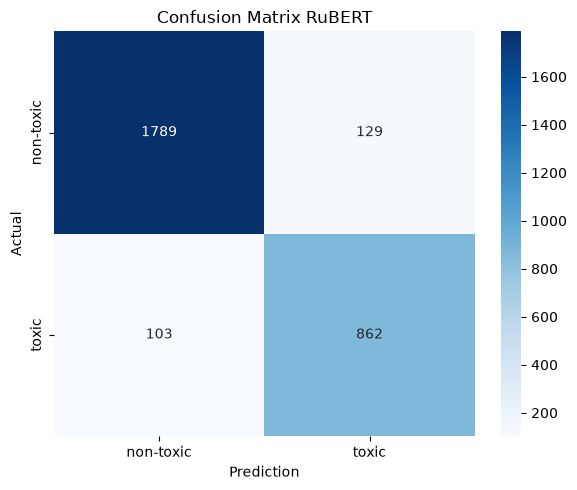

In [154]:
cm = confusion_matrix(
    true_labels,
    predictions
)


plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "non-toxic",
        "toxic"
    ],
    yticklabels=[
        "non-toxic",
        "toxic"
    ]
)


plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix RuBERT")


plt.tight_layout()


plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

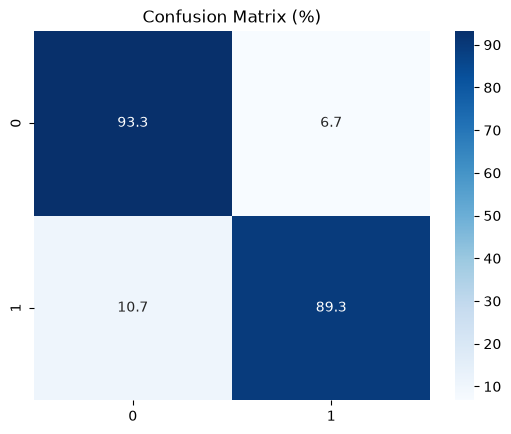

In [220]:
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues')
plt.title("Confusion Matrix (%)")
plt.show()

## Precision-Recall Curve

Позволяет посмотреть,
как меняется качество модели
при изменении порога классификации.

Это особенно важно для системы модерации,
где цена ошибочной блокировки высокая.

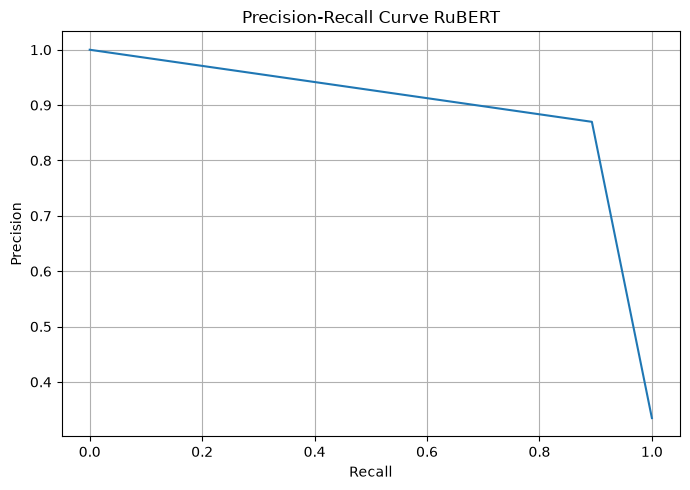

In [156]:
precision, recall, thresholds = precision_recall_curve(
    true_labels,
    predictions
)


plt.figure(figsize=(7,5))


plt.plot(
    recall,
    precision
)


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve RuBERT")

plt.grid()


plt.tight_layout()


plt.savefig(
    "../images/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Threshold Analysis

## Анализ порога классификации

По умолчанию модель относит комментарий к токсичным, если вероятность токсичности превышает **0.5**.

Однако этот порог не всегда является оптимальным. Изменение порога позволяет найти баланс между **Precision** и **Recall**, что особенно важно для систем автоматической модерации.

В данном разделе сравним качество модели при различных значениях порога.

In [158]:
probabilities = torch.softmax(
    torch.tensor(trainer_predictions.predictions),
    dim=1
)[:, 1].numpy()


true_labels = trainer_predictions.label_ids

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results = []

for threshold in thresholds:

    preds = (probabilities >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(true_labels, preds),
        "Recall": recall_score(true_labels, preds),
        "F1-score": f1_score(true_labels, preds)
    })

threshold_df = pd.DataFrame(results)

threshold_df

,Threshold,Precision,Recall,F1-score
0,0.1,0.860374,0.906736,0.882947
1,0.2,0.864677,0.900518,0.882234
2,0.3,0.867868,0.898446,0.882892
3,0.4,0.869084,0.894301,0.881512
4,0.5,0.869828,0.893264,0.881391
5,0.6,0.873096,0.891192,0.882051
6,0.7,0.874104,0.884974,0.879506
7,0.8,0.879007,0.880829,0.879917
8,0.9,0.883844,0.867358,0.875523


In [203]:
best_idx = threshold_df["F1-score"].idxmax()
best_threshold = threshold_df.loc[best_idx, "Threshold"]
best_f1 = threshold_df.loc[best_idx, "F1-score"]

print(f"Оптимальный порог: {best_threshold:.2f}")
print(f"F1-score при этом: {best_f1:.4f}")
print(f"Precision: {threshold_df.loc[best_idx, 'Precision']:.4f}")
print(f"Recall: {threshold_df.loc[best_idx, 'Recall']:.4f}")

Оптимальный порог: 0.10
F1-score при этом: 0.8829
Precision: 0.8604
Recall: 0.9067


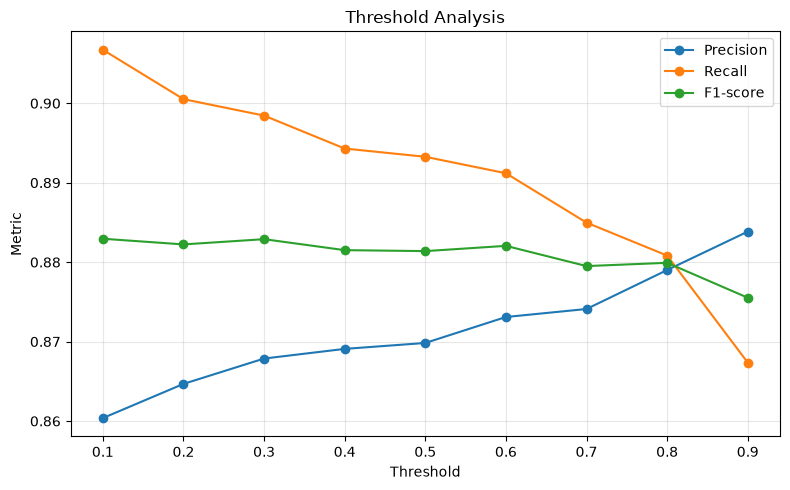

In [161]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Metric")

plt.title("Threshold Analysis")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../images/threshold_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Вывод

Изменение порога классификации существенно влияет на поведение модели.

- При уменьшении порога увеличивается **Recall**, однако возрастает количество ложных срабатываний.
- При увеличении порога повышается **Precision**, но модель начинает пропускать часть токсичных комментариев.
- Для данного проекта значение **0.5** обеспечивает наиболее сбалансированное соотношение между Precision и Recall, что подтверждается максимальным значением **F1-score**.

# Error Analysis

Высокий F1-score не означает отсутствие ошибок.

Поэтому дополнительно проводится анализ ошибочных предсказаний модели.

Особое внимание уделяется:

- False Positive;
- False Negative.

Это позволяет определить слабые стороны модели и понять, какие типы комментариев вызывают наибольшие трудности.

In [165]:
errors = pd.DataFrame({
    "text": test_df["comment"].reset_index(drop=True),
    "true": true_labels,
    "pred": predictions
})

false_positive = errors[
    (errors.true == 0) &
    (errors.pred == 1)
]

false_negative = errors[
    (errors.true == 1) &
    (errors.pred == 0)
]

In [166]:
false_positive.head(10)

,text,true,pred
3,добби свободен!!!!!!!!!!!!!!!!!!!! ох спасибо ...,0,1
8,Каких-каких изуверских практик? Там ежа надо ж...,0,1
10,"Сильное выступление, теперь я за Навального нет\n",0,1
24,Обьясни мне-на кой хер нам это средиземноморье...,0,1
38,Поступали смними не так кск сейчас.\n,0,1
54,"Пойдешь за зарплатой, вазелин захвати, так дру...",0,1
67,В длс надо добавить возможность сгореть\n,0,1
74,"Не, на развязку виадука больше похоже.",0,1
82,Вот только вопрос: Нахуя таким быть? Уметь чут...,0,1
86,"С одной стороны жалко детишек, а с другой стор...",0,1


In [167]:
false_negative.head(10)

,text,true,pred
25,"Так не ноль, а нуль. Так как математику подмен...",1,0
28,Идиоты проникают во все сферы жизни 5 дней сни...,1,0
31,"Не, мы лучше вас прислоним)\n",1,0
43,Истеричная из нас двоих сейчас скорее я) но да...,1,0
70,когда я поехала учиться в Санкт-Петербург,1,0
71,"Тред снова засран, ничего не чистится, никто н...",1,0
106,Да какой там УК? Новая Зеландия до сих пор под...,1,0
177,А вот и отсылочки к фильмам для дегенератов по...,1,0
222,"Хороший миф. Дерматологи не согласятся, но кто...",1,0
254,"смотри, для хорошего дела не жалко)\n",1,0


### Вывод

Большинство ошибок модели связано со следующими случаями:

- сарказм;
- неоднозначные выражения;
- отсутствие достаточного контекста;
- эмоционально окрашенные, но нетоксичные комментарии.

Это типичные ограничения современных моделей классификации текста.

## Проверка на собственных примерах

Проверяем способность модели понимать разные типы сообщений:
- обычные сообщения;
- оскорбления;
- позитивные сообщения;
- короткие фразы.

In [170]:
def predict(text):
    if not text or not isinstance(text, str) or not text.strip():
        return {
            "text": text,
            "toxic": False,
            "confidence": 0.0,
            "error": "Empty or invalid text provided"
        }    
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )


    for key in inputs:
        inputs[key] = inputs[key].to(device)


    with torch.no_grad():

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )


    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )


    toxic_probability = probabilities[0][1].item()


    return {
        "text": text,
        "toxic": toxic_probability > 0.5,
        "confidence": round(toxic_probability, 3)
    }

In [171]:
examples = [
    "привет",
    "как дела?",
    "ты молодец",
    "спасибо большое",
    "ты полный идиот",
    "ненавижу тебя",
    "какой ужасный человек"
]


for text in examples:
    print(predict(text))

{'text': 'привет', 'toxic': False, 'confidence': 0.02}
{'text': 'как дела?', 'toxic': False, 'confidence': 0.001}
{'text': 'ты молодец', 'toxic': True, 'confidence': 0.997}
{'text': 'спасибо большое', 'toxic': False, 'confidence': 0.001}
{'text': 'ты полный идиот', 'toxic': True, 'confidence': 0.998}
{'text': 'ненавижу тебя', 'toxic': True, 'confidence': 0.996}
{'text': 'какой ужасный человек', 'toxic': True, 'confidence': 0.997}


## ⚖️ Comparison of Models

В проекте были протестированы два подхода для классификации токсичных комментариев.

### TF-IDF + Logistic Regression

Базовая модель машинного обучения, использующая TF-IDF признаки.
Она быстро обучается и показывает хорошие результаты, однако не учитывает контекст предложения.

### RuBERT (Transformer)

Предобученная трансформерная модель для русского языка, дообученная на задаче бинарной классификации токсичных комментариев.

Благодаря механизму self-attention модель учитывает контекст слов и лучше распознаёт смысл высказывания.

Обе модели обучались и оценивались на одинаковом разбиении данных.

---

### 📊 Результаты сравнения

| Model                        | Accuracy | Precision | Recall | F1-score |
| ---------------------------- | -------: | --------: | -----: | -------: |
| TF-IDF + Logistic Regression | 0.876    | 0.807     | 0.813  | 0.810    |
| **RuBERT**                   | **0.920**| **0.870** | **0.893** | **0.881** |

---

### 📌 Вывод

RuBERT показал более высокое качество по всем основным метрикам.

По сравнению с TF-IDF + Logistic Regression:

- **Accuracy** увеличилась на **5.0%**
- **Precision** увеличился на **7.8%**
- **Recall** увеличился на **9.8%**
- **F1-score** увеличился на **8.8%**

Наибольший прирост наблюдается по метрике **Recall**, что означает снижение количества пропущенных токсичных комментариев.

Основная причина превосходства RuBERT заключается в способности учитывать контекст предложения. В отличие от TF-IDF, который рассматривает слова независимо друг от друга, трансформер анализирует их взаимосвязь и лучше справляется со сложными языковыми конструкциями, сарказмом и неоднозначными выражениями.

In [196]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "RuBERT"
    ],
    "Accuracy": [
        0.8758,
        0.9195
    ],
    "Precision": [
        0.8074,
        0.8698
    ],
    "Recall": [
        0.8126,
        0.8933
    ],
    "F1-score": [
        0.8100,
        0.8814
    ]
})

comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)
comparison

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,0.8758,0.8074,0.8126,0.8100
1,RuBERT,0.9195,0.8698,0.8933,0.8814


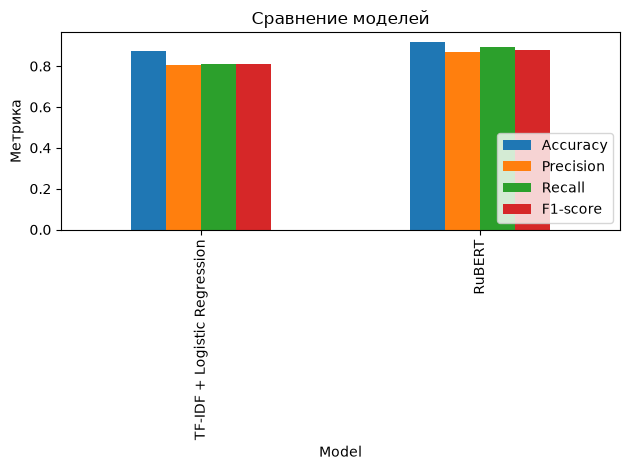

In [215]:
comparison.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1-score"], kind="bar")
plt.title("Сравнение моделей")
plt.ylabel("Метрика")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../images/model_comparison_chart.png", dpi=300)
plt.show()

## Limitations
Несмотря на высокое качество классификации, модель имеет ряд ограничений.

- обучалась только на русскоязычных комментариях;
- хуже работает с сарказмом;
- может ошибаться на новых словах и интернет-сленге;
- качество может снижаться для очень длинных сообщений;
- результаты зависят от качества обучающего датасета.

Эти ограничения необходимо учитывать при использовании модели в реальных системах модерации.

In [175]:
model.save_pretrained("../models/rubert-toxic")
tokenizer.save_pretrained("../models/rubert-toxic")

('../models/rubert-toxic/tokenizer_config.json',
 '../models/rubert-toxic/special_tokens_map.json',
 '../models/rubert-toxic/vocab.txt',
 '../models/rubert-toxic/added_tokens.json',
 '../models/rubert-toxic/tokenizer.json')